In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

# from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
# drop all rows where run column is 5
r_table = r_table[r_table['run'] != 5]
r_table.run.unique()

array([0, 1, 2, 3, 4])

## Real

In [3]:
def impute_with_median(data):
    median_rt = np.nanmedian(data)
    rt_imputed = data.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

### Calculating RT and evidence for 5 different choices

In [4]:
r_table[["subj", "target", "t_calib", "resp"]].head()

,subj,target,t_calib,resp
0,1,159.0,145.788047,148.685925
1,1,123.0,136.060195,129.253756
2,1,51.0,33.954344,124.965094
3,1,159.0,145.788047,145.702460
4,1,15.0,18.896223,144.334808


In [5]:
r_table

,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,exp,nn,1sig,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir
0,1,0,0,0,159.0,145.788047,148.685925,2.897877,2.897877,145.788047,145.788047,1.0,1.0,1.0,divided,high,expected,132,373,higher
1,1,0,0,1,123.0,136.060195,129.253756,6.806439,-6.806439,145.788047,136.060195,1.0,1.0,1.0,focused,high,unexpected,204,280,lower
2,1,0,0,2,51.0,33.954344,124.965094,91.010750,91.010750,145.788047,136.060195,0.0,0.0,0.0,focused,high,unexpected,168,250,higher
3,1,0,0,3,159.0,145.788047,145.702460,0.085587,-0.085587,145.788047,145.788047,1.0,1.0,1.0,divided,high,expected,168,337,lower
4,1,0,0,4,15.0,18.896223,144.334808,125.438585,125.438585,145.788047,145.788047,0.0,0.0,0.0,divided,low,unexpected,180,270,higher
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34435,12,3,4,115,123.0,138.552340,142.623254,4.070914,4.070914,3.855904,138.552340,1.0,1.0,1.0,divided,high,unexpected,156,346,higher
34436,12,3,4,116,15.0,3.855904,143.110793,139.254889,139.254889,3.855904,138.552340,0.0,0.0,0.0,focused,low,expected,168,436,higher
34437,12,3,4,117,15.0,3.855904,28.548542,24.692638,24.692638,3.855904,37.827708,0.0,0.0,0.0,focused,low,expected,168,360,higher
34438,12,3,4,118,15.0,3.855904,24.793549,20.937645,20.937645,3.855904,37.827708,0.0,1.0,0.0,divided,low,expected,204,340,higher


   subj      att   coh      exp_al        rt  choice
0     1  divided  high    expected  1.025000       4
1     1  focused  high  unexpected  0.250000       3
2     1  divided  high    expected  0.725000       4
3     1  divided   low  unexpected  0.166667       4
4     1  divided   low    expected  0.658333       4


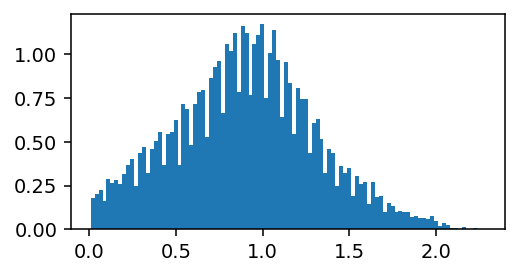

In [6]:
data = r_table[['subj', "att", "coh", "exp_al", "target", "resp"]].copy()

raw_rt = (r_table['f_resp'].values - 250) * (1/120)
# aug_rt = impute_with_lin_interpolation(raw_rt)

col_to_angle = {0: 15, 1: 51, 2: 87, 3: 123, 4: 159}
def map_response(subj, resp):
    # select row for subject (1-indexed)
    row = med[subj - 1]
    # find index of closest representative angle
    idx = np.abs(row - resp).argmin()
    return col_to_angle[idx]
data['afc_resp'] = data.apply(lambda r: map_response(r['subj'], r['resp']), axis=1)

resp = data['afc_resp'].map(median_key)

data['rt'] = raw_rt
data['choice'] = resp

# drop where rt == 0
data = data[data['rt'] != 0].reset_index(drop=True)

print(data[['subj', "att", "coh", "exp_al", "rt", "choice"]].head())

plt.figure(figsize=(4, 2))
# plt.hist(data.rt.sample(n=200, replace=False, random_state=42).values.flatten(), bins=100, density=True)
plt.hist(data.rt.values.flatten(), bins=100, density=True)
plt.show()

In [7]:
# Condition masks
masks = [
    data.att == "focused",
    data.att == "divided",
    data.coh == "high",
    data.coh == "low",
    data.exp_al == "expected",
    data.exp_al == "unexpected"
]

rts = []
resps = []
for mask in masks:
    rt = []
    rs = []
    for sid in data.subj.unique():
        sub_data = data[mask & (data.subj == sid)]
        sample = sub_data.sample(n=500, replace=False, random_state=42)
        
        rt.append(sample.rt.values)
        rs.append(sample.choice.values)
    rts.append(rt)
    resps.append(rs)

rts = np.array(rts) # / 1000 # convert to seconds
resps = np.array(resps)

rts.shape, resps.shape

((6, 12, 500), (6, 12, 500))

### Fitting

In [8]:
import math
import numpy as np
import pytensor
import pytensor.tensor as pt
import pandas as pd

from tqdm import tqdm

from scipy.optimize import minimize
import matplotlib.pyplot as plt

AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

In [ ]:
def broadcast(n, A, b, v, s, tau):
    def _promote(x):
        x_var = pt.constant(x) if not hasattr(x, "ndim") else x
        if x_var.ndim == 0:return pt.repeat(x_var, n)
        if x_var.ndim == 1:return x_var
        raise ValueError(f"Scalars or 1-D tensor of dim {n} only, got ndim={x_var.ndim}")
    return (_promote(x) for x in (A, b, v, s, tau))

def LBA(rt, response, n, A, b, v, s, tau=0):
    """PDF of Linear Ballistic Accumulator model."""

    # Ensure inputs are not mangled
    A, b, v, s, tau = broadcast(n, A, b, v, s, tau)

    # Standard normal PDF and CDF
    normpdf = lambda x: pt.exp(-0.5 * x**2) / pt.sqrt(2 * math.pi)
    normcdf = lambda x: 0.5 * (1 + pt.erf(x / math.sqrt(2)))

    def tpdf(t, A, b, v, s):
        """First-passage time probability density function for single accumulator."""
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # First-passage density formula
        pdf = (1/A) * (-v * normcdf(g) + s * normpdf(g) + v * normcdf(h) - s * normpdf(h))

        return pt.maximum(pdf, 1e-20)  # Numerical stability

    def tcdf(t, A, b, v, s):
        """First-passage time cumulative distribution function for single accumulator."""
        
        # Calculate standardized variables
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # CDF components
        p1 = ((b - A - t * v) / A) * normcdf(g)
        p2 = ((b - t * v) / A) * normcdf(h)
        p3 = ((t * s) / A) * normpdf(g)
        p4 = ((t * s) / A) * normpdf(h)
        
        cdf = 1 + p1 - p2 + p3 - p4

        # Ensure CDF is between 0 and 1
        return pt.clip(cdf, 1e-20, 1 - 1e-20)
    
    # First‐passage densities for each accumulator
    f = pt.stack([ tpdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # shape (m, n_trials)
    F = pt.stack([tcdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # CDFs for each accumulator
    p_zero = pt.prod(normcdf(-v / s)) # Probability that none ever finish

    # For each i: f_i * ∏_{j≠i} (1 − F_j)
    numer = pt.stack([
        f[i] * pt.prod(1 - pt.concatenate([F[:i], F[i+1:]]), axis=0)
        for i in range(n)
    ], axis=0)
    
    # Select density + normalize
    pdf = numer[response, pt.arange(rt.shape[0])] / (1 - p_zero) 

    # Zero out trials where rt ≤ τ for that accumulator
    t = rt - tau[response]
    return pt.switch(pt.gt(t, 0), pdf, 1e-20)

In [ ]:
def crossval_lba(df, param, n_acc, eval_split=0.3, seed=None):
    """
    Cross-validate an LBA fit by optimizing exactly one 'unknown' parameter.

    Args:
        df (pd.DataFrame): must have 'rt' (float) and 'response' (int) cols.
        param (dict): e.g. {'A':4, 'b':8, 'v':'unknown', 's':1, 'tau':0}.
                      Exactly one value must be the string 'unknown'.
        n_acc (int): number of accumulators.
        eval_split (float): fraction for test set (default 0.3). If 0, use full data.
        seed (int|None): RNG seed for reproducibility.
    Returns:
        recovered_params (dict): same keys as `param`, but 'unknown' replaced
                                 by an array of length n_acc with MLEs.
        test_loglik (float): sum of log p(rt,response) on the test or full set.
    """
    # 1) Extract RT & resp arrays
    rt_all   = df['rt'].to_numpy()
    resp_all = df['response'].to_numpy()
    rng = np.random.default_rng(seed)

    # 2) Train/test split (or use full data)
    if eval_split <= 0:
        rt_train, resp_train = rt_all, resp_all
        rt_test,  resp_test  = rt_all, resp_all
    else:
        idx = rng.permutation(len(df))
        n_test = int(len(df) * eval_split)
        test_idx, train_idx = idx[:n_test], idx[n_test:]
        rt_train, resp_train = rt_all[train_idx], resp_all[train_idx]
        rt_test,  resp_test  = rt_all[test_idx],  resp_all[test_idx]

    # 3) Identify the unknown parameter
    unknowns = [k for k, v in param.items() if v == 'unknown']
    if len(unknowns) != 1:
        raise ValueError("`param` must have exactly one value=='unknown'")
    unk = unknowns[0]

    # 4) Collect fixed parameters (use LBA's internal broadcast)
    fixed = {k: param[k] for k in param if k != unk}

    # 5) PyTensor symbols
    unk_var  = pt.vector(unk)
    rt_var   = pt.vector('rt')
    resp_var = pt.ivector('resp')

    # 6) Assemble symbolic params
    sym_params = {}
    for k in ('A', 'b', 'v', 's', 'tau'):
        if k == unk:
            sym_params[k] = unk_var
        else:
            sym_params[k] = pt.constant(fixed[k])

    # 7) Define train neg-loglik + grad
    p_train       = LBA(rt_var, resp_var, n_acc, **sym_params)
    nll_train     = -pt.sum(pt.log(p_train + 1e-12))
    grad_train    = pt.grad(nll_train, unk_var)
    f_and_g_train = pytensor.function(
        [unk_var, rt_var, resp_var],
        [nll_train, grad_train]
    )

    # 8) Define test neg-loglik
    p_test     = LBA(rt_var, resp_var, n_acc, **sym_params)
    nll_test   = -pt.sum(pt.log(p_test + 1e-12))
    f_nll_test = pytensor.function([unk_var, rt_var, resp_var], nll_test)

    # 9) Optimize on training set
    x0     = rng.uniform(1e-5, 5, size=n_acc)
    bounds = [(1e-5, 5.0)] * n_acc
    def fun_and_grad(x):
        nll, grad = f_and_g_train(x, rt_train, resp_train)
        return float(nll), np.array(grad, dtype=float)

    result  = minimize(
        fun_and_grad,
        x0,
        method='L-BFGS-B',
        jac=True,
        bounds=bounds
    )
    recovered = result.x

    # 10) Evaluate test log-likelihood
    test_nll = f_nll_test(recovered, rt_test, resp_test)
    test_ll  = float(-test_nll)

    # 11) Build recovered params dict
    recovered_params = {k: (recovered if k == unk else fixed[k])
                        for k in ('A', 'b', 'v', 's', 'tau')}

    return recovered_params, test_ll

In [ ]:
def init_lba_guess(df, lower_tau_q=0.1, upper_b_q=0.9):
    """
    Heuristic initialization of LBA parameters from empirical RT data.

    Args:
        df (pd.DataFrame): contains 'rt' column of response times.
        lower_tau_q (float): quantile for non-decision time tau and A.
        upper_b_q (float): quantile for threshold b.
    Returns:
        dict with keys 'A', 'b', 'v', 's', 'tau', where:
          - A and tau are floats,
          - b, v, and s are lists of lengt.
    """
    rt = df['rt'].to_numpy()
    # 1) non-decision time: lower quantile of RT
    tau = float(np.quantile(rt, lower_tau_q))
    # 2) decision times
    dt = np.clip(rt - tau, a_min=1e-3, a_max=None)
    # 3) starting-point range
    A = float(np.quantile(dt, lower_tau_q))
    # 4) threshold
    b = float(np.quantile(dt, upper_b_q))
    # 5) drift rate via mean decision time
    v = float(b / np.mean(dt))
    # 6) drift variability
    s = float(np.std(dt))
    return {
        'A': A,
        'b': b,
        'v': v,
        's': s,
        'tau': tau,
    }

In [ ]:
init_params = init_lba_guess(data, lower_tau_q=0.1, upper_b_q=0.9)
init_params

{'A': 0.001,
 'b': 1.0833333333333335,
 'v': 1.8996836469311227,
 's': 0.383333783521071,
 'tau': 0.3416666666666667}

In [ ]:
conditions = ["focused", "divided", "high", "low", "expected", "unexpected"]
param_vars = ["A", "b", "v", "s", "tau"]

In [ ]:

param_by_param_res = []

for param in param_vars:

    t_param = init_params.copy()
    t_param[param] = 'unknown'

    crossval_ll = {k: [] for k in conditions}

    for cond in tqdm(range(6)):
        for sub_idx in range(12):

            rt = rts[cond, sub_idx]
            choices = resps[cond, sub_idx].astype('int32')

            df = pd.DataFrame({
                "rt": rt,
                "response": choices
            })
            
            par, ll = crossval_lba(df, t_param, n_acc=5, eval_split=0.3, seed=42)

            crossval_ll[conditions[cond]].append(ll)

    param_by_param_res.append((param, crossval_ll))


100%|██████████| 6/6 [05:04<00:00, 50.80s/it]


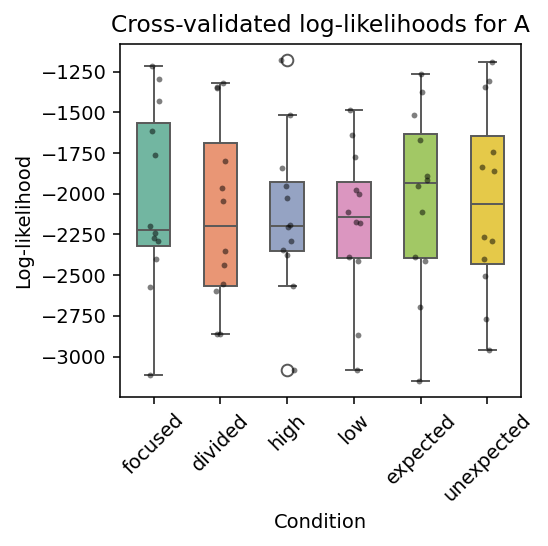

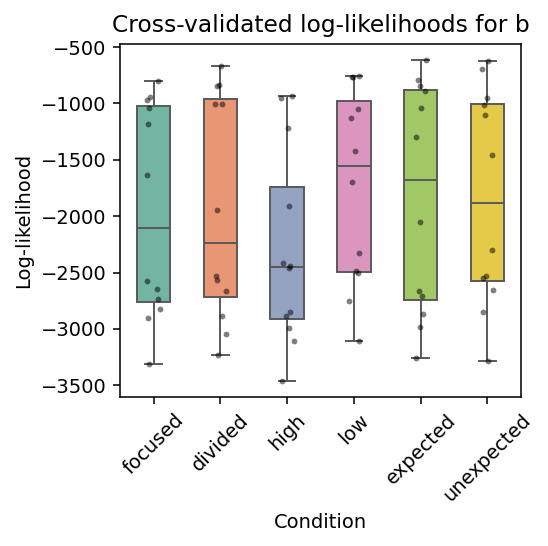

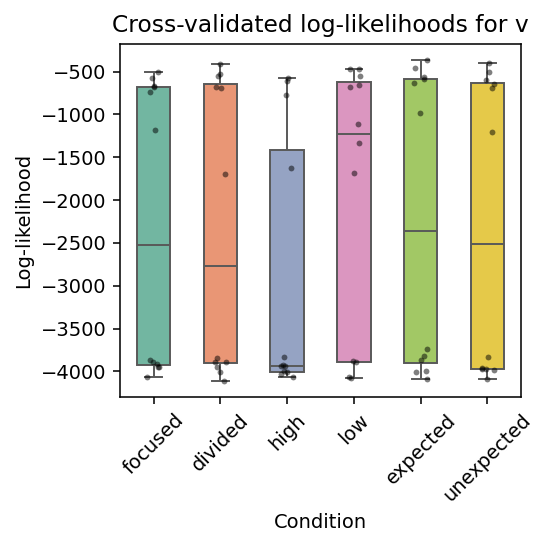

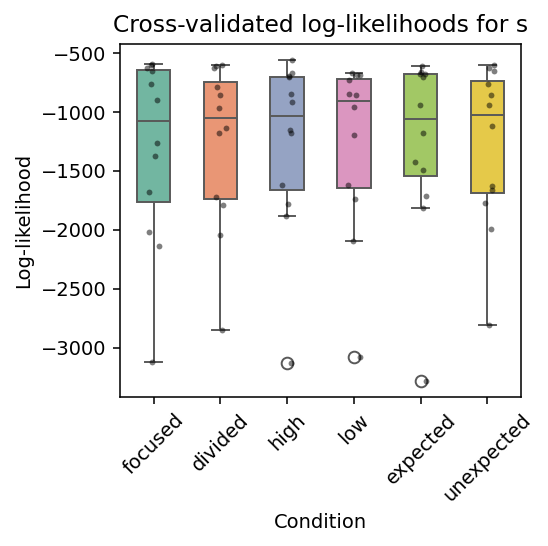

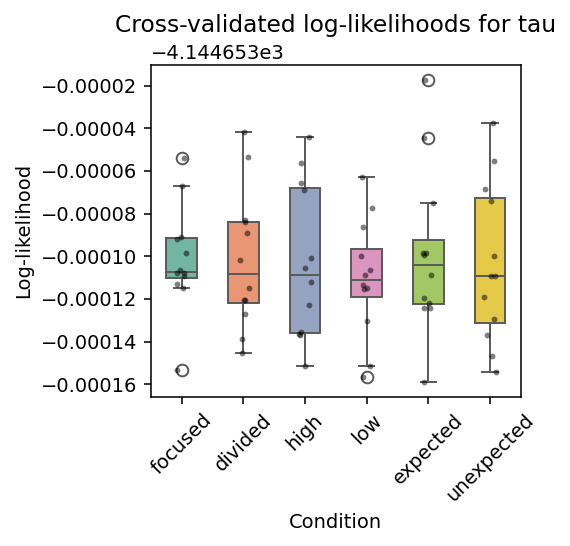

In [ ]:
# Loop through param_by_param_res 
# for each of those, plot the cross-validated log-likelihoods in y axis and conditions in x axis
# sns box plot with jittered data scattered on it. there should be 6 boxes, one for each condition abd 12 dots in each box for each subject


for param, ll in param_by_param_res:
    plt.figure(figsize=(4, 4))
    sns.boxplot(data=pd.DataFrame(ll), palette="Set2", width=0.5)
    sns.stripplot(data=pd.DataFrame(ll), color='black', alpha=0.5, jitter=True, size=3)
    
    plt.title(f"Cross-validated log-likelihoods for {param}")
    plt.xlabel("Condition")
    plt.ylabel("Log-likelihood")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

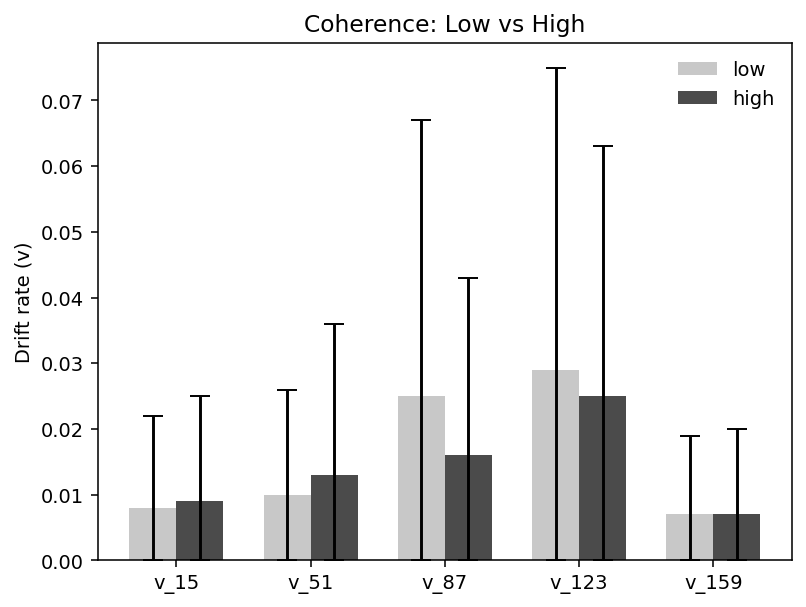

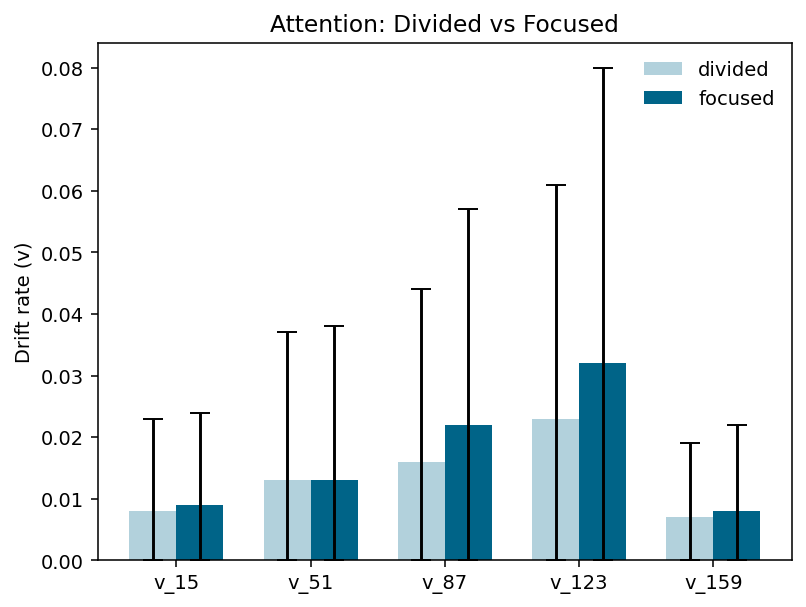

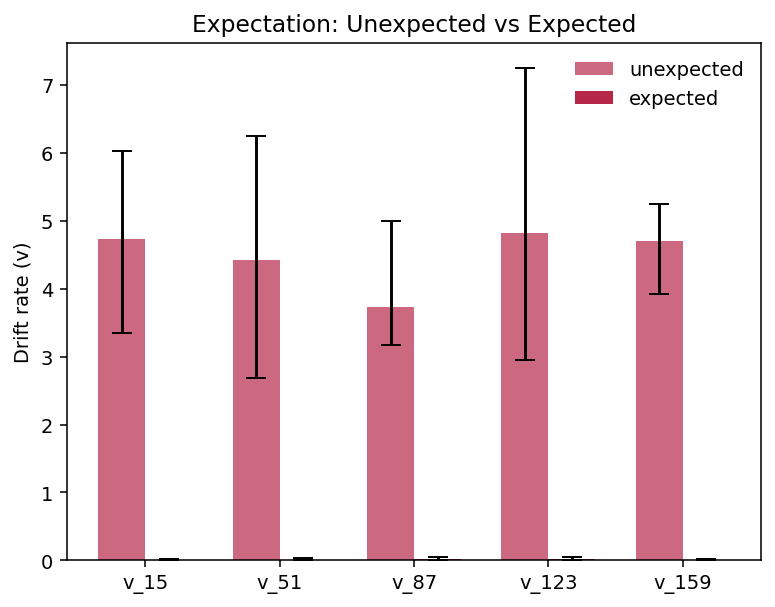

In [ ]:
comparisons = [
    ("low", "high", "Coherence"),
    ("divided", "focused", "Attention"),
    ("unexpected", "expected", "Expectation")
]

colors = [("#c8c8c8", "#4b4b4b"), ("#b2d1dc", "#006488"), ("#cc6980", "#b62748")]

for (cond1, cond2, title), (color1, color2) in zip(comparisons, colors):
    df1 = summs[cond1]
    df2 = summs[cond2]

    # Extract means and HDIs
    means1 = df1['mean'].to_numpy()
    means2 = df2['mean'].to_numpy()
    lower1 = means1 - df1['hdi_3%'].to_numpy()
    upper1 = df1['hdi_97%'].to_numpy() - means1
    lower2 = means2 - df2['hdi_3%'].to_numpy()
    upper2 = df2['hdi_97%'].to_numpy() - means2

    # X positions
    x = range(len(means1))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar([xi - width/2 for xi in x], means1, width, label=cond1, 
           yerr=[lower1, upper1], capsize=5, color=color1)
    ax.bar([xi + width/2 for xi in x], means2, width, label=cond2, 
           yerr=[lower2, upper2], capsize=5, color=color2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"v_{col_to_angle[i]}" for i in x])
    ax.set_title(f"{title}: {cond1.capitalize()} vs {cond2.capitalize()}")
    ax.set_ylabel("Drift rate (v)")
    ax.legend( loc='upper right', frameon=False)
    plt.show()


In [ ]:
conditions = ["focused", "divided", "high", "low", "expected", "unexpected"]
params = {"A": 0.5, "b": None, "v": 1.0, "s": 1.0, "tau": 0.1},

summs = {}
idatas = {}

subj = 9
for condition in range(6):
    rt = rts[condition, 9]
    choices = resps[condition, 9].astype('int32')
    idata = fit_one(
        5, rt, choices,
        draws=500, tune=200, chains=4,
        **param,
    )
    summs[conditions[condition]] = az.summary(idata)
    idatas[conditions[condition]] = idata

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 605 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


...

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 513 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 21 seconds.
There were 387 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


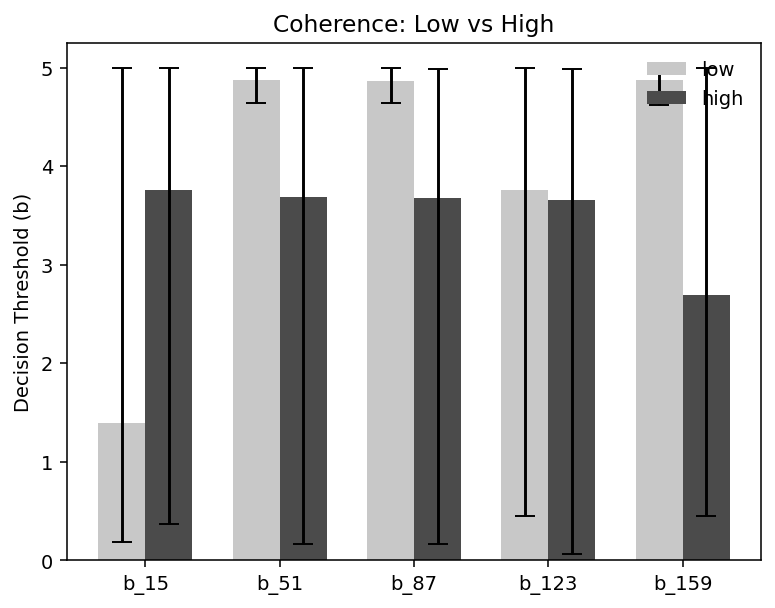

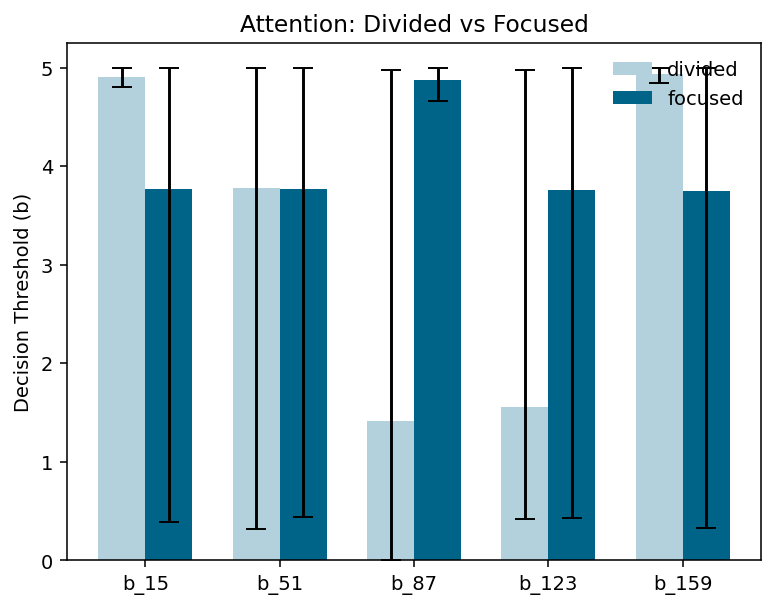

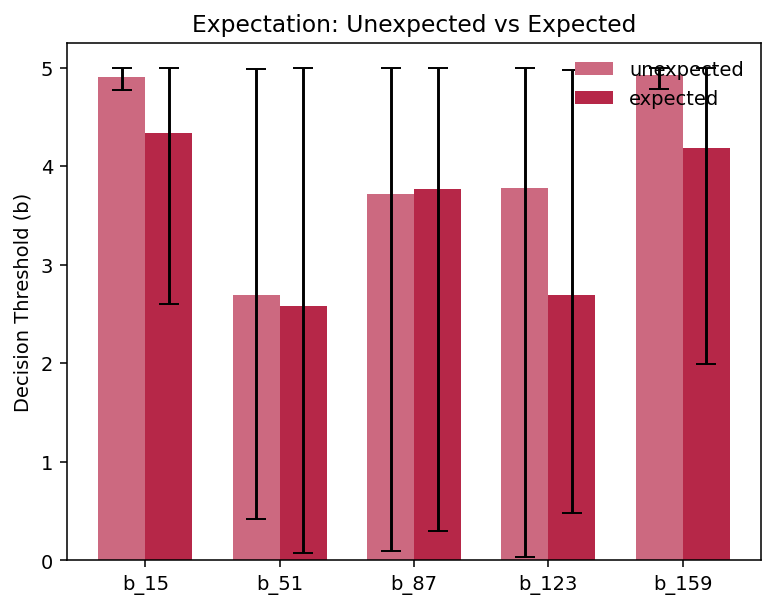

In [ ]:
comparisons = [
    ("low", "high", "Coherence"),
    ("divided", "focused", "Attention"),
    ("unexpected", "expected", "Expectation")
]

colors = [("#c8c8c8", "#4b4b4b"), ("#b2d1dc", "#006488"), ("#cc6980", "#b62748")]

for (cond1, cond2, title), (color1, color2) in zip(comparisons, colors):
    df1 = summs[cond1]
    df2 = summs[cond2]

    # Extract means and HDIs
    means1 = df1['mean'].to_numpy()
    means2 = df2['mean'].to_numpy()
    lower1 = means1 - df1['hdi_3%'].to_numpy()
    upper1 = df1['hdi_97%'].to_numpy() - means1
    lower2 = means2 - df2['hdi_3%'].to_numpy()
    upper2 = df2['hdi_97%'].to_numpy() - means2

    # X positions
    x = range(len(means1))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar([xi - width/2 for xi in x], means1, width, label=cond1, 
           yerr=[lower1, upper1], capsize=5, color=color1)
    ax.bar([xi + width/2 for xi in x], means2, width, label=cond2, 
           yerr=[lower2, upper2], capsize=5, color=color2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"b_{col_to_angle[i]}" for i in x])
    ax.set_title(f"{title}: {cond1.capitalize()} vs {cond2.capitalize()}")
    ax.set_ylabel("Decision Threshold (b)")
    ax.legend( loc='upper right', frameon=False)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.lines import Line2D

def plot_lba_multi(A, b, v, vcolors, tau):

    # Generate random start points within [0, A]
    y0s = np.random.uniform(0, A, size=len(v))
    # Compute dx for each trajectory and overall max for limits
    dx_vals = [(b - y0) / vi for y0, vi in zip(y0s, v)]
    max_dx = max(dx_vals)
    
    fig, ax = plt.subplots(figsize=(6, 4))

    # 1) Annotate τ on x-axis
    ax.annotate('', xy=(0, 0), xytext=(tau, 0),
                arrowprops=dict(arrowstyle='<->', linewidth=1.5))
    ax.text(tau / 2, -0.05 * b, 'τ', ha='center', va='top')

    # 2) Draw each evidence trajectory starting at (tau, y0s[i])
    for yi, vi, color in zip(y0s, v, vcolors):
        dx = (b - yi) / vi
        x0, x1 = tau, tau + dx
        ax.annotate('', xy=(x1, b), xytext=(x0, yi),
                    arrowprops=dict(arrowstyle='->', color=color, linewidth=2),
                    zorder=1)

    # 3) Draw the start-point range bar on top to hide trajectory bases
    bar_w = 0.02 * (tau + max_dx)
    rect = patches.Rectangle((tau, 0), bar_w, A,
                             facecolor='grey', alpha=0.7, zorder=2)
    ax.add_patch(rect)

    # 4) Annotate A at left of the bar
    ax.annotate('', xy=(tau, 0), xytext=(tau, A),
                arrowprops=dict(arrowstyle='<->', linewidth=1.5))
    ax.text(tau - 0.02 * (tau + max_dx), A / 2, 'A', ha='right', va='center')

    # 5) Threshold line and label
    ax.hlines(b, 0, tau + max_dx * 1.1, linestyles='--', color='k')
    ax.text(-0.05 * (tau + max_dx), b, 'b', ha='right', va='center')

    # 6) Axes labels & styling
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Accumulated evidence')
    ax.set_xlim(-0.1 * (tau + max_dx), tau + max_dx * 1.1)
    ax.set_ylim(0, b + 0.2 * A)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Build legend entries manually
    legend_lines = [
        Line2D([0], [0], color=vcolors[i], lw=2)
        for i in range(len(v))
    ]
    legend_labels = [f"v₍{col_to_angle[i]}°₎ = {v[i]:.2f}" for i in range(len(v))]

    ax.legend(legend_lines, legend_labels, title="Drift rates", loc="lower right", frameon=False)
    ax.set_title(f"Condition: {cond.capitalize()}")

    plt.show()


In [ ]:


# Mapping from column index to angle
col_to_angle = {0: 15, 1: 51, 2: 87, 3: 123, 4: 159}

# Colors for each drift index
vcolors = ['C0', 'C1', 'C2', 'C3', 'C4']

# Fixed LBA params (example values, adjust as needed)
A_fixed = 4.0
b_fixed = 4.0
sv_fixed = 1.0
tau_fixed = 0.2

# Loop through each condition in summs
for cond, df_sum in summs.items():
    # Extract the posterior mean of each drift rate v[0]...v[4]
    v_means = df_sum['mean'].values  # array of length 5

    # Plot the LBA schematic with multiple drifts
    plot_lba_multi(A=A_fixed, b=b_fixed, v=v_means, vcolors=vcolors, tau=tau_fixed)
